In [1]:
from dataclasses import dataclass
from typing_extensions import Self
from typing import Callable
import numpy as np
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import structural_similarity as ssim
from torchvision import transforms
from torch.utils.data import DataLoader
from torch import nn
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from tqdm import tqdm
import torch

# %matplotlib widget

from typing import Optional
import matplotlib.pyplot as plt
import torch

from pileup_ml.detectors.pixels import PixelDetector, PixelModule
from pileup_ml.pixels.hits import PixelDigiEvent
from pileup_ml.pixels.patches import (
    PixelModulePatches, PixelEventPatches, _PixelEventGrid,
    event_hits_to_patches, module_patches_to_hits, event_patches_to_hits)
from pileup_ml.compression.metrics import compare_matching_hits, compare_hit_presence

from pileup_ml.compression.base import CompressedPixelEvent
from numpy import cov, trace, iscomplexobj
from scipy.linalg import sqrtm
from torch.utils.data import random_split
from torchmetrics.regression import MeanSquaredError
from matplotlib.gridspec import GridSpec


In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

<h3>CMS pileup data compression based on VQ-VAE compression</h3>

Experiment comments and insights:
* Codebook entries from 256 vectors (rows), only approximately 120 codebook entries are used effectively based perplexity
* Reconstruction improves with bigger latent vector and num embeddings. Reducing codebook size, improves usage but not reconstruction quality
* Validation set properly works with higher beta coeficient roughly from beta in [0.2, 0.31]
* Codebook plots describe codebook variation, whether certain weights are mostly zero (grey color) and are codebook usage is not sparse (orange colors)
* Making encoded patch d > 2, we do not loose any information and perplexity does not collapse. When latent vector is flat, codebook usage is lower but not harms reconstruction

Utility function import and prepearation

In [3]:
from helpers.model_tool import ModelTool
from helpers.data_tool import CMSDataTool, \
                                CMSPlots, \
                                PixelPatchesDataset

<h3>Helper objects</h3>

In [4]:
model_tool = ModelTool()
cms_data_tool = CMSDataTool()
cms_plots = CMSPlots()

<h3>Helper constants</h3>

In [5]:
SELECTED_EVENTS = 1
EVENT_COUNT = 1
PATCH_SIZE = 8
BITS_HIT = 25 
LOG_EVERY = 15

<h3>Data loading</h3>

In [6]:
# Loading data
pixel_modules = PixelModule.read_json('/data/cern/pileup_ml/detid_info/detids_bpix.json', '/data/cern/pileup_ml/detid_info/detids_fpix.json')
pix_det = PixelDetector(pixel_modules)

events_train_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0001.root', pix_det)
events_train = events_train_all[:EVENT_COUNT]

events_test_all = PixelDigiEvent.read_root('/data/cern/pileup_ml/premixlib2024/0002.root', pix_det)
events_test = events_test_all[:EVENT_COUNT]

100%|██████████| 1000/1000 [00:04<00:00, 240.47it/s]


<h3>VQ-VAE Hyperparameters</h3>

In [7]:
batch_size = 64
beta = 0.49
# beta = 0.98

# beta = 1 0.
# beta is possible in interval [4e-3, 8e-3]

# 0.1, 0.08 - on the right track

learning_rate = 1e-3
model_param_scale = 5
# model_param_scale = 1 (right order)
# learning_rate = 1e-3 (right on track)

num_epochs = 200
# num_epochs = 1

# input channels
channels = 1 # since grayscale images are used, we go with 1 channel images
hidden_channels = 64

# how many codebook entries
num_embeddings = 256
# num_embeddings = 32 (on track)

latent_dim = 32
# latent_dim = 64 (on track)

# Residual layer config
residual_channels = 32
residual_layers = 2

# Latent dimension size
d = 2 # adjustable encoder width for extra compression


In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [9]:
mse = MeanSquaredError()
mse = mse.to(device)

In [10]:
seed_value = 123

if device.type == "cuda":
    torch.cuda.manual_seed_all(seed_value)
else:
    torch.cuda.manual_seed(seed_value)

In [11]:
event_train = events_train[:SELECTED_EVENTS][0]

In [12]:
patch_amount = cms_data_tool._get_patch_count(event_train)
total_hit_amount = len(event_train)

print(f"Total patch amount: {patch_amount}")
print(f"Total hits: {total_hit_amount}")

Total patch amount: 15857
Total hits: 48169


<h3>Data preprocessing</h3>

<h3>Data loading</h3>

In [13]:
# Data preprocessing

transform = transforms.Compose([
    transforms.ToTensor(),
])

event_dataset = PixelPatchesDataset(event_train, PATCH_SIZE, transform)
dataset_size = len(event_dataset)

train_size = int(0.8 * dataset_size)
val_size = int(0.02 * dataset_size)
test_size = dataset_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    event_dataset,
    [train_size, val_size, test_size]
)

# # Training data prepearation

train_loader = DataLoader(
    dataset=train_dataset, 
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    dataset=val_dataset, 
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    dataset=test_dataset, 
    batch_size=batch_size,
    shuffle=False
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 12685
Validation set size: 317
Test set size: 2855


<h3>VAE Binary Cross Entropy loss for VQ-VAE</h3>

In [14]:
def _get_vae_loss(
    recon_x: torch.tensor, 
    x: torch.tensor
) -> float:
    recon_loss = F.binary_cross_entropy(recon_x, x, reduction="mean")
    return recon_loss

<h3>VQ-VAE model</h3>

In [15]:
# Goal of Vector Quantization is to solve posterior collapse problem

class VectorQuantizer(nn.Module):
    """
    Discretization bottleneck part of the VQ-VAE.

    Inputs:
    - n_e : number of embeddings
    - e_dim : dimension of embedding
    - beta : commitment cost used in loss term, beta * ||z_e(x)-sg[e]||^2
    """

    def __init__(self, n_e, e_dim, beta):
        super(VectorQuantizer, self).__init__()
        self.n_e = n_e
        self.e_dim = e_dim
        self.beta = beta

        self.embedding = nn.Embedding(self.n_e, self.e_dim)
        self.embedding.weight.data.uniform_(-1.0 / self.n_e, 1.0 / self.n_e)

    def forward(self, z):
        """
        Inputs the output of the encoder network z and maps it to a discrete
        one-hot vector that is the index of the closest embedding vector e_j

        z (continuous) -> z_q (discrete)

        z.shape = (batch, channel, height, width)

        quantization pipeline:

            1. get encoder input (B,C,H,W)
            2. flatten input to (B*H*W,C)

        """
        # reshape z -> (batch, height, width, channel) and flatten
        # z = z.permute(0, 2, 3, 1).contiguous()
        z_flattened = z.view(-1, self.e_dim).contiguous()
        # distances from z to embeddings e_j (z - e)^2 = z^2 + e^2 - 2 e * z

        # NOTE: is a matrix learnable vector for learning codebook indices. 
        codebook = self.embedding.weight
        
        # Euclidean distance for finding closest codebooks
        d = torch.sum(z_flattened ** 2, dim=1, keepdim=True) + \
            torch.sum(self.embedding.weight**2, dim=1) - 2 * \
            torch.matmul(z_flattened, codebook.t())
            
        # Result -> d gets dimensions from matrix torch.matmul(z_flattened, self.embedding.weight.t())
        # embedding weight t is defined by num_embeddings, latent_dim
        # --------------------
            
        # find closest encodings
        min_encoding_indices = torch.argmin(d, dim=1).unsqueeze(1)
        min_encodings = torch.zeros(
            min_encoding_indices.shape[0], self.n_e).to(device)
        
        # perform one hot encoding
        min_encodings.scatter_(1, min_encoding_indices, 1)

        # NOTE: selects weights form embedding weight and puts them based on one hot encoding
        z_q = torch.matmul(min_encodings, codebook).view(z.shape)
        
        # beta - commitment cost used in loss term
        
        # compute loss for embedding
        loss = torch.mean((z_q.detach() - z)**2) + self.beta * \
            torch.mean((z_q - z.detach()) ** 2)

        # preserve gradients with preservation trick. Allows gradients to exist
        # (z_q - z.detach() )- is like a constant

        # We make quantized latent space vector to get closer to the encoder output
        # we highliht the codewords and gradually each epoch we force neaigoboring pixels
        # to be associating with cendroids
        z_q = z + (z_q - z).detach()

        # perplexity - average of weights of probabilities
        e_mean = torch.mean(min_encodings, dim=0)
        
        # Measures how many codebook vectors are beeing used
        perplexity = torch.exp(-torch.sum(e_mean * torch.log(e_mean + 1e-10)))

        # reshape back to match original input shape
        # contiguous() is used for improving performance
        # z_q = z_q.permute(0, 3, 1, 2).contiguous()

        return loss, z_q, perplexity, min_encodings, min_encoding_indices, codebook

In [16]:
class ResidualLayer(nn.Module):
    """
    One residual layer inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    """

    def __init__(self, in_dim, h_dim, res_h_dim, slope):
        super(ResidualLayer, self).__init__()
        self.res_block = nn.Sequential(
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(in_dim, res_h_dim, kernel_size=3,
                      stride=1, padding=1, bias=False),
            nn.LeakyReLU(negative_slope=slope, inplace=True),
            nn.Conv2d(res_h_dim, h_dim, kernel_size=1,
                      stride=1, bias=False)
        )

    def forward(self, x):
        x = x + self.res_block(x)
        return x


class ResidualStack(nn.Module):
    """
    A stack of residual layers inputs:
    - in_dim : the input dimension
    - h_dim : the hidden layer dimension
    - res_h_dim : the hidden dimension of the residual block
    - n_res_layers : number of layers to stack
    """

    def __init__(self, in_dim, h_dim, res_h_dim, n_res_layers, slope):
        super(ResidualStack, self).__init__()
        self.n_res_layers = n_res_layers
        self.slope = slope
        self.stack = nn.ModuleList(
            [
                ResidualLayer(in_dim, h_dim, res_h_dim, slope)
                for _ in range(n_res_layers)
            ])

    def forward(self, x):
        for layer in self.stack:
            x = layer(x)
        x = F.relu(x)
        return x

In [17]:
# TODO: think about it later
class AbstractModule(nn.Module):
    
    def __init__(self) -> None:
        super().__init__()
    
    def forward(self, x: torch.tensor) -> None:
        raise NotImplemented

In [18]:
# TODO: test with 2 x 2 encoded patch

class EncoderInput(AbstractModule):
    
    # NOTE: encoder_features - from convolution network
    """
    d: int - how many codebook indexes could an encoded patch have    
    encoder_features: int - how many features are in encoder convolution output 
    
    """
    def __init__(self, d: int, slope: np.float64, encoder_features: int = 2) -> None:
        super().__init__()
        
        self.latent_dim = latent_dim
        
        # TODO: in_features need to come from encoder conv network
        self.encoder_features = encoder_features
        self.layers = nn.Sequential(
            nn.Linear(in_features=encoder_features, out_features=d),
            nn.BatchNorm1d(d),
            nn.LeakyReLU(slope)
        )
        
    def forward(self, x: torch.tensor) -> None:
        x_output = self.layers(x)
        return x_output
    

class DecoderInput(AbstractModule):
    
    # NOTE: decoder_features - dinamically add required feature count for decoder
    
    """
    d: int - how many indexes could an encoded patch have
    decoder_features: int - how many features could a decoder convolution network have
    """
    
    def __init__(self, d: int, slope: np.float64, latent_dim: int, decoder_features: int = 2) -> None:
        super().__init__()
        
        self.latent_dim = latent_dim
        self.layers = nn.Sequential(
            nn.Linear(in_features=d, out_features=decoder_features),
            nn.BatchNorm1d(decoder_features),
            nn.LeakyReLU(slope)
        )
        self.decoder_features = decoder_features
        
    def forward(self, x: torch.tensor) -> None:
        dec_out = self.layers(x)
        return dec_out
    

In [19]:
# Comments
# kernel_size = 4 - preserves spatial repesentations (coordinates)
class VQVAE(nn.Module):
    
    def __init__(
        self, 
        hidden_channels: int, 
        kernel_size: int, 
        slope: float,
        res_h_dim: int,
        n_res_layers: int,
        d: int,
        residual_slope: float = 0.08,
    ) -> None:
        super().__init__()
        
        self.encoder = nn.Sequential(   
            nn.Conv2d(channels, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),  
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.Conv2d(hidden_channels, hidden_channels * 2, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            nn.LeakyReLU(slope),            
            nn.Conv2d(hidden_channels * 2, latent_dim, kernel_size=kernel_size-1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, latent_dim),
            ResidualStack(latent_dim, latent_dim, res_h_dim, n_res_layers, residual_slope)
        )
        
        # fully connected layer for encoder input
        self.fc_encoder_input = EncoderInput(d=d, slope=slope)     
        
        self.vq_layer = VectorQuantizer(num_embeddings, latent_dim, beta)
        
        # fully connected layer for vq input
        self.fc_decoder_input = DecoderInput(d=d, latent_dim=latent_dim, slope=slope)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, hidden_channels * 2, kernel_size=kernel_size - 1, stride=1, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels * 2),
            ResidualStack(hidden_channels * 2, hidden_channels * 2, res_h_dim, n_res_layers, residual_slope),
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.GroupNorm(8, hidden_channels),
            nn.LeakyReLU(slope),
            nn.ConvTranspose2d(hidden_channels, channels, kernel_size=kernel_size, stride=2, padding=1, bias=False),
            nn.Sigmoid()
        )

        
    def forward(self, x):
        encoder_output = self.encoder(x)
        b, c, w, h = encoder_output.shape
        encoder_flatten = encoder_output.view(b * c * h, w)
        
        z = self.fc_encoder_input(encoder_flatten)
        
        (
            recon_loss, 
            z_q, 
            perplexity, 
            min_encodings, 
            min_encoding_indices, 
            codebook
        ) = self.vq_layer(z)
        
        z_q = self.fc_decoder_input(z_q)
        decoder_input = z_q.view(b, c, h, w)
        
        output = self.decoder(decoder_input)
        
        return (
            output, 
            codebook, 
            z_q,
            perplexity, 
            recon_loss 
        )

In [20]:
model = VQVAE(
    hidden_channels=hidden_channels, 
    kernel_size = 4,
    slope=0.1,
    d=d,
    n_res_layers=residual_layers, # residual hidden layers
    res_h_dim=residual_channels # residual hidden channels
).to(device)

optimizer = optim.Adam(
    model.parameters(), 
    lr=learning_rate, 
    amsgrad=True
)

<h3>VQ-VAE training loop</h3>

Epoch 1/200: 100%|██████████| 199/199 [00:00<00:00, 257.22it/s, Loss (BCE + VQ)=0.206]


Epoch [1/200] summary:Average Loss: VQ + BCE = 0.5041,  Average loss: BCE = 0.0802 MSE = 0.009714849241751821 avg_perplexity = 3.43737548080521
Average validation set BCE loss: 0.07320832386612892
Before compression (Training)
Shape: (13, 8, 8)


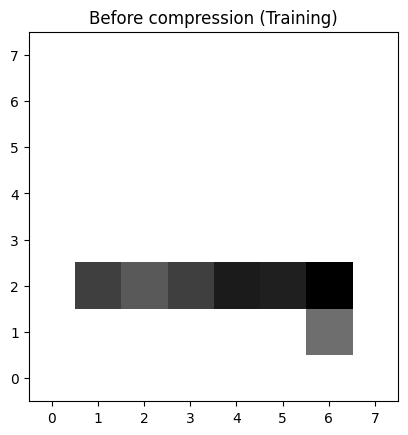

After compression (Training)
Shape: (1, 8, 8)


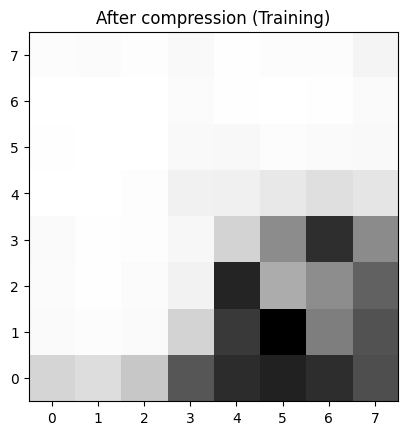

Epoch 2/200: 100%|██████████| 199/199 [00:00<00:00, 331.46it/s, Loss (BCE + VQ)=0.12]  


Epoch [2/200] summary:Average Loss: VQ + BCE = 0.1461,  Average loss: BCE = 0.0701 MSE = 0.007664389409892373 avg_perplexity = 2.833390281428045
Average validation set BCE loss: 0.0662754200398922


Epoch 3/200: 100%|██████████| 199/199 [00:00<00:00, 337.48it/s, Loss (BCE + VQ)=0.0922]


Epoch [3/200] summary:Average Loss: VQ + BCE = 0.0913,  Average loss: BCE = 0.0650 MSE = 0.007302186351232044 avg_perplexity = 4.40882157560569
Average validation set BCE loss: 0.0658323422074318


Epoch 4/200: 100%|██████████| 199/199 [00:00<00:00, 346.09it/s, Loss (BCE + VQ)=0.0611]


...

Epoch [14/200] summary:Average Loss: VQ + BCE = 0.0652,  Average loss: BCE = 0.0547 MSE = 0.006120802151348124 avg_perplexity = 5.651688578140796
Average validation set BCE loss: 0.05571679025888443


Epoch 15/200: 100%|██████████| 199/199 [00:00<00:00, 332.39it/s, Loss (BCE + VQ)=0.0563]


Epoch [15/200] summary:Average Loss: VQ + BCE = 0.0648,  Average loss: BCE = 0.0542 MSE = 0.006061775121959535 avg_perplexity = 5.684471887559747
Average validation set BCE loss: 0.05393608510494232


Epoch 16/200: 100%|██████████| 199/199 [00:00<00:00, 325.63it/s, Loss (BCE + VQ)=0.0425]


Epoch [16/200] summary:Average Loss: VQ + BCE = 0.0641,  Average loss: BCE = 0.0540 MSE = 0.006033460731295186 avg_perplexity = 5.73790451989102
Average validation set BCE loss: 0.0538596510887146
Before compression (Training)
Shape: (13, 8, 8)


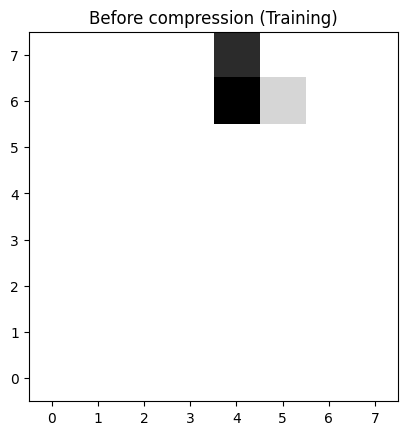

After compression (Training)
Shape: (1, 8, 8)


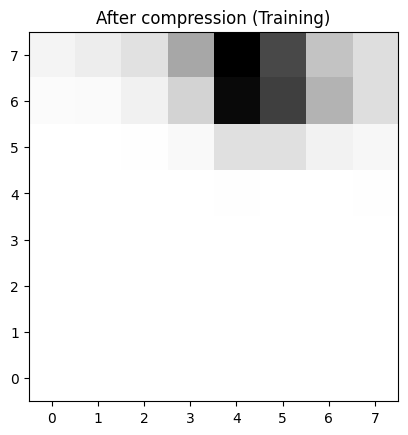

Epoch 17/200: 100%|██████████| 199/199 [00:00<00:00, 317.61it/s, Loss (BCE + VQ)=0.0706]


Epoch [17/200] summary:Average Loss: VQ + BCE = 0.0631,  Average loss: BCE = 0.0535 MSE = 0.005978488640616363 avg_perplexity = 5.816649072733357
Average validation set BCE loss: 0.054162435978651044


Epoch 18/200: 100%|██████████| 199/199 [00:00<00:00, 321.66it/s, Loss (BCE + VQ)=0.0524]


Epoch [18/200] summary:Average Loss: VQ + BCE = 0.0624,  Average loss: BCE = 0.0529 MSE = 0.005879387913515145 avg_perplexity = 5.930829069722238
Average validation set BCE loss: 0.05286414250731468


Epoch 19/200: 100%|██████████| 199/199 [00:00<00:00, 327.30it/s, Loss (BCE + VQ)=0.0877]


...

Epoch [29/200] summary:Average Loss: VQ + BCE = 0.0553,  Average loss: BCE = 0.0462 MSE = 0.004773854336528173 avg_perplexity = 7.35074950222993
Average validation set BCE loss: 0.045802678912878036


Epoch 30/200: 100%|██████████| 199/199 [00:00<00:00, 324.64it/s, Loss (BCE + VQ)=0.0436]


Epoch [30/200] summary:Average Loss: VQ + BCE = 0.0548,  Average loss: BCE = 0.0459 MSE = 0.004723382981531509 avg_perplexity = 7.380772935685201
Average validation set BCE loss: 0.045286723971366884


Epoch 31/200: 100%|██████████| 199/199 [00:00<00:00, 317.54it/s, Loss (BCE + VQ)=0.0486]


Epoch [31/200] summary:Average Loss: VQ + BCE = 0.0547,  Average loss: BCE = 0.0459 MSE = 0.004709325492119969 avg_perplexity = 7.352136839574306
Average validation set BCE loss: 0.04509632736444473
Before compression (Training)
Shape: (13, 8, 8)


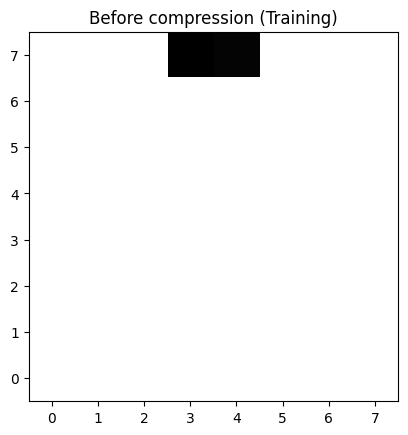

After compression (Training)
Shape: (1, 8, 8)


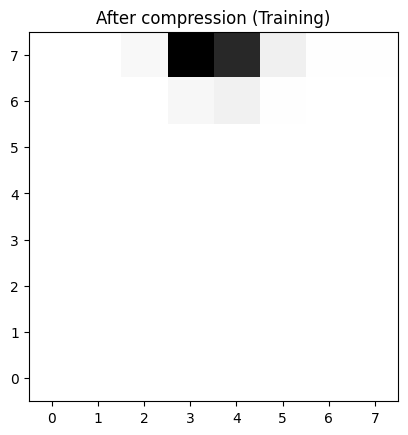

Epoch 32/200: 100%|██████████| 199/199 [00:00<00:00, 316.02it/s, Loss (BCE + VQ)=0.0438]


Epoch [32/200] summary:Average Loss: VQ + BCE = 0.0547,  Average loss: BCE = 0.0458 MSE = 0.004706932371014252 avg_perplexity = 7.379232495274376
Average validation set BCE loss: 0.045368749648332596


Epoch 33/200: 100%|██████████| 199/199 [00:00<00:00, 345.09it/s, Loss (BCE + VQ)=0.0413]


Epoch [33/200] summary:Average Loss: VQ + BCE = 0.0546,  Average loss: BCE = 0.0457 MSE = 0.004691529210572641 avg_perplexity = 7.36320670046399
Average validation set BCE loss: 0.045016710460186


Epoch 34/200: 100%|██████████| 199/199 [00:00<00:00, 343.95it/s, Loss (BCE + VQ)=0.0432]


...

Epoch [44/200] summary:Average Loss: VQ + BCE = 0.0525,  Average loss: BCE = 0.0442 MSE = 0.004435288041231021 avg_perplexity = 7.704196381209484
Average validation set BCE loss: 0.04345171228051185


Epoch 45/200: 100%|██████████| 199/199 [00:00<00:00, 325.74it/s, Loss (BCE + VQ)=0.0516]


Epoch [45/200] summary:Average Loss: VQ + BCE = 0.0523,  Average loss: BCE = 0.0440 MSE = 0.004400838597036486 avg_perplexity = 7.73294475210372
Average validation set BCE loss: 0.043441245704889296


Epoch 46/200: 100%|██████████| 199/199 [00:00<00:00, 342.98it/s, Loss (BCE + VQ)=0.0429]


Epoch [46/200] summary:Average Loss: VQ + BCE = 0.0520,  Average loss: BCE = 0.0439 MSE = 0.0043982301099253955 avg_perplexity = 7.800596565457445
Average validation set BCE loss: 0.04292463585734367
Before compression (Training)
Shape: (13, 8, 8)


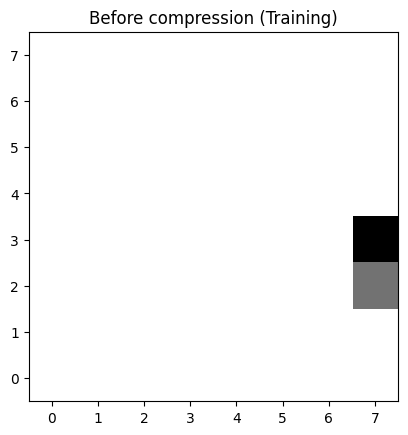

After compression (Training)
Shape: (1, 8, 8)


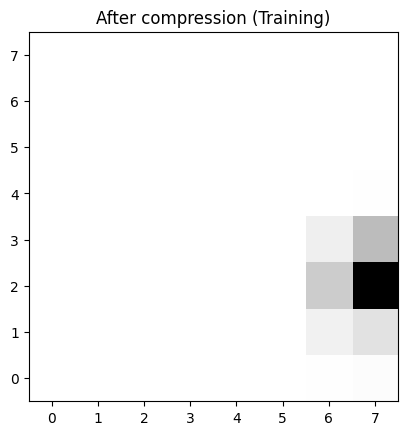

Epoch 47/200: 100%|██████████| 199/199 [00:00<00:00, 327.40it/s, Loss (BCE + VQ)=0.0859]


Epoch [47/200] summary:Average Loss: VQ + BCE = 0.0520,  Average loss: BCE = 0.0439 MSE = 0.004379268777767318 avg_perplexity = 7.773834772445449
Average validation set BCE loss: 0.043348432332277295


Epoch 48/200: 100%|██████████| 199/199 [00:00<00:00, 338.54it/s, Loss (BCE + VQ)=0.0631]


Epoch [48/200] summary:Average Loss: VQ + BCE = 0.0520,  Average loss: BCE = 0.0437 MSE = 0.004347755340859294 avg_perplexity = 7.836018555128395
Average validation set BCE loss: 0.04314950108528137


Epoch 49/200: 100%|██████████| 199/199 [00:00<00:00, 324.67it/s, Loss (BCE + VQ)=0.0416]


...

Epoch [59/200] summary:Average Loss: VQ + BCE = 0.0485,  Average loss: BCE = 0.0407 MSE = 0.0037690569756636816 avg_perplexity = 9.006072691337547
Average validation set BCE loss: 0.041377491503953936


Epoch 60/200: 100%|██████████| 199/199 [00:00<00:00, 316.97it/s, Loss (BCE + VQ)=0.0463]


Epoch [60/200] summary:Average Loss: VQ + BCE = 0.0485,  Average loss: BCE = 0.0406 MSE = 0.003739085404118102 avg_perplexity = 9.00183823839504
Average validation set BCE loss: 0.041002257168293


Epoch 61/200: 100%|██████████| 199/199 [00:00<00:00, 332.76it/s, Loss (BCE + VQ)=0.0441]


Epoch [61/200] summary:Average Loss: VQ + BCE = 0.0481,  Average loss: BCE = 0.0404 MSE = 0.003724216565433609 avg_perplexity = 9.0096059492485
Average validation set BCE loss: 0.04162577241659164
Before compression (Training)
Shape: (13, 8, 8)


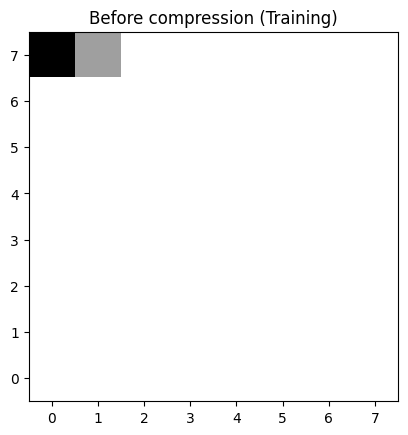

After compression (Training)
Shape: (1, 8, 8)


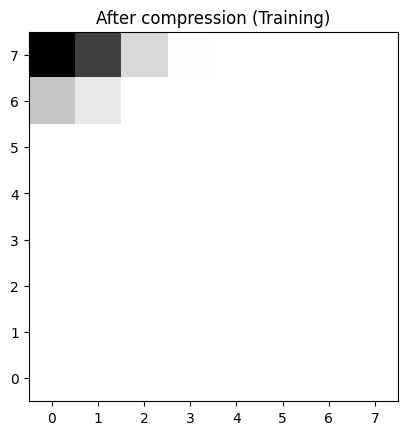

Epoch 62/200: 100%|██████████| 199/199 [00:00<00:00, 330.63it/s, Loss (BCE + VQ)=0.0424]


Epoch [62/200] summary:Average Loss: VQ + BCE = 0.0479,  Average loss: BCE = 0.0402 MSE = 0.0036854605101535667 avg_perplexity = 9.026170519728158
Average validation set BCE loss: 0.04183618500828743


Epoch 63/200: 100%|██████████| 199/199 [00:00<00:00, 318.96it/s, Loss (BCE + VQ)=0.0396]


Epoch [63/200] summary:Average Loss: VQ + BCE = 0.0478,  Average loss: BCE = 0.0401 MSE = 0.0036824988306560858 avg_perplexity = 9.03985801533838
Average validation set BCE loss: 0.04097252115607262


Epoch 64/200: 100%|██████████| 199/199 [00:00<00:00, 314.97it/s, Loss (BCE + VQ)=0.0586]


...

Epoch [74/200] summary:Average Loss: VQ + BCE = 0.0467,  Average loss: BCE = 0.0392 MSE = 0.0034779914357610533 avg_perplexity = 9.153831036246602
Average validation set BCE loss: 0.03963380977511406


Epoch 75/200: 100%|██████████| 199/199 [00:00<00:00, 343.05it/s, Loss (BCE + VQ)=0.032] 


Epoch [75/200] summary:Average Loss: VQ + BCE = 0.0464,  Average loss: BCE = 0.0390 MSE = 0.0034336317277948686 avg_perplexity = 9.155377632409484
Average validation set BCE loss: 0.04052496328949928


Epoch 76/200: 100%|██████████| 199/199 [00:00<00:00, 343.15it/s, Loss (BCE + VQ)=0.0436]


Epoch [76/200] summary:Average Loss: VQ + BCE = 0.0465,  Average loss: BCE = 0.0390 MSE = 0.0034643222563829853 avg_perplexity = 9.17121528261271
Average validation set BCE loss: 0.0403078481554985
Before compression (Training)
Shape: (13, 8, 8)


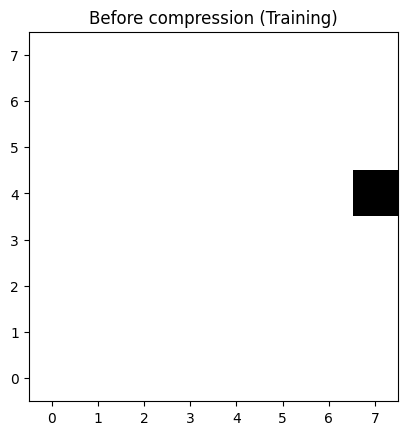

After compression (Training)
Shape: (1, 8, 8)


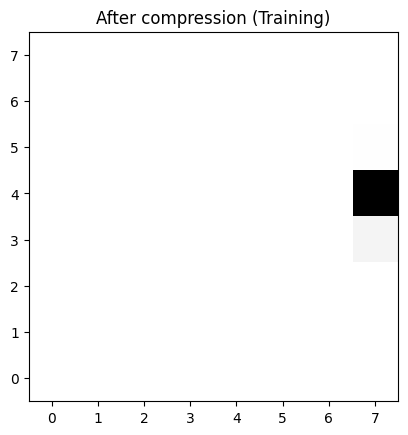

Epoch 77/200: 100%|██████████| 199/199 [00:00<00:00, 323.44it/s, Loss (BCE + VQ)=0.043] 


Epoch [77/200] summary:Average Loss: VQ + BCE = 0.0465,  Average loss: BCE = 0.0390 MSE = 0.0034574316054039713 avg_perplexity = 9.181835914976034
Average validation set BCE loss: 0.04013924971222878


Epoch 78/200: 100%|██████████| 199/199 [00:00<00:00, 340.95it/s, Loss (BCE + VQ)=0.0316]


Epoch [78/200] summary:Average Loss: VQ + BCE = 0.0465,  Average loss: BCE = 0.0390 MSE = 0.00345554321550357 avg_perplexity = 9.181944935765099
Average validation set BCE loss: 0.04060069248080254


Epoch 79/200: 100%|██████████| 199/199 [00:00<00:00, 332.91it/s, Loss (BCE + VQ)=0.0475]


...

Epoch [89/200] summary:Average Loss: VQ + BCE = 0.0453,  Average loss: BCE = 0.0382 MSE = 0.0032868401226985393 avg_perplexity = 9.23299003006825
Average validation set BCE loss: 0.04009130299091339


Epoch 90/200: 100%|██████████| 199/199 [00:00<00:00, 343.51it/s, Loss (BCE + VQ)=0.0509]


Epoch [90/200] summary:Average Loss: VQ + BCE = 0.0459,  Average loss: BCE = 0.0385 MSE = 0.0033647444885430023 avg_perplexity = 9.223092242101927
Average validation set BCE loss: 0.03967481330037117


Epoch 91/200: 100%|██████████| 199/199 [00:00<00:00, 341.93it/s, Loss (BCE + VQ)=0.0411]


Epoch [91/200] summary:Average Loss: VQ + BCE = 0.0457,  Average loss: BCE = 0.0384 MSE = 0.003328577510605393 avg_perplexity = 9.233387491810861
Average validation set BCE loss: 0.03970687314867973
Before compression (Training)
Shape: (13, 8, 8)


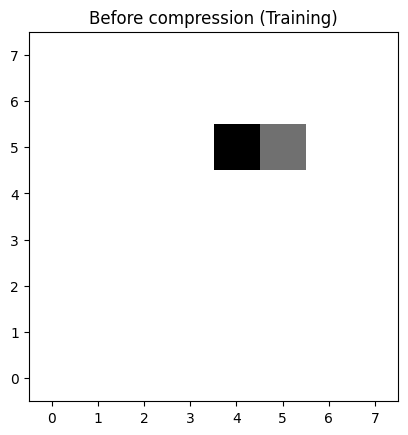

After compression (Training)
Shape: (1, 8, 8)


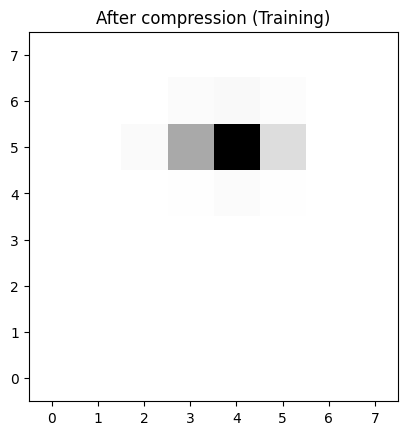

Epoch 92/200: 100%|██████████| 199/199 [00:00<00:00, 327.27it/s, Loss (BCE + VQ)=0.0395]


Epoch [92/200] summary:Average Loss: VQ + BCE = 0.0454,  Average loss: BCE = 0.0383 MSE = 0.0033064716759994253 avg_perplexity = 9.232586668963409
Average validation set BCE loss: 0.040695735812187196


Epoch 93/200: 100%|██████████| 199/199 [00:00<00:00, 336.69it/s, Loss (BCE + VQ)=0.0439]


Epoch [93/200] summary:Average Loss: VQ + BCE = 0.0456,  Average loss: BCE = 0.0382 MSE = 0.0032945071761238966 avg_perplexity = 9.2847731173338
Average validation set BCE loss: 0.039443351328372955


Epoch 94/200: 100%|██████████| 199/199 [00:00<00:00, 346.27it/s, Loss (BCE + VQ)=0.0402]


...

Epoch [104/200] summary:Average Loss: VQ + BCE = 0.0444,  Average loss: BCE = 0.0377 MSE = 0.003201575059415632 avg_perplexity = 9.584479653056542
Average validation set BCE loss: 0.040067197382450105


Epoch 105/200: 100%|██████████| 199/199 [00:00<00:00, 328.07it/s, Loss (BCE + VQ)=0.0367]


Epoch [105/200] summary:Average Loss: VQ + BCE = 0.0445,  Average loss: BCE = 0.0377 MSE = 0.0031965522156401195 avg_perplexity = 9.574066753962532
Average validation set BCE loss: 0.03985129073262215


Epoch 106/200: 100%|██████████| 199/199 [00:00<00:00, 336.73it/s, Loss (BCE + VQ)=0.0322]


Epoch [106/200] summary:Average Loss: VQ + BCE = 0.0449,  Average loss: BCE = 0.0379 MSE = 0.0032435680731391562 avg_perplexity = 9.590300301211563
Average validation set BCE loss: 0.0393575519323349
Before compression (Training)
Shape: (13, 8, 8)


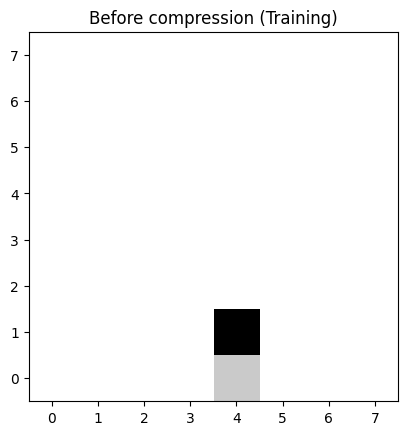

After compression (Training)
Shape: (1, 8, 8)


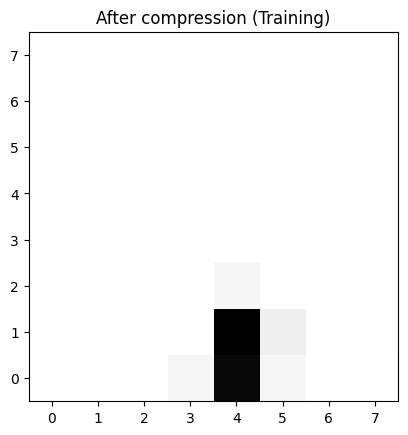

Epoch 107/200: 100%|██████████| 199/199 [00:00<00:00, 325.74it/s, Loss (BCE + VQ)=0.0636]


Epoch [107/200] summary:Average Loss: VQ + BCE = 0.0446,  Average loss: BCE = 0.0377 MSE = 0.003200567385354945 avg_perplexity = 9.577799375332779
Average validation set BCE loss: 0.039731786400079724


Epoch 108/200: 100%|██████████| 199/199 [00:00<00:00, 334.84it/s, Loss (BCE + VQ)=0.0367]


Epoch [108/200] summary:Average Loss: VQ + BCE = 0.0444,  Average loss: BCE = 0.0376 MSE = 0.003181665568336395 avg_perplexity = 9.581496962350817
Average validation set BCE loss: 0.04142597913742065


Epoch 109/200: 100%|██████████| 199/199 [00:00<00:00, 346.33it/s, Loss (BCE + VQ)=0.0427]


...

Epoch [119/200] summary:Average Loss: VQ + BCE = 0.0439,  Average loss: BCE = 0.0372 MSE = 0.003117869498123925 avg_perplexity = 9.74957672195818
Average validation set BCE loss: 0.0399572029709816


Epoch 120/200: 100%|██████████| 199/199 [00:00<00:00, 346.57it/s, Loss (BCE + VQ)=0.0464]


Epoch [120/200] summary:Average Loss: VQ + BCE = 0.0439,  Average loss: BCE = 0.0372 MSE = 0.003108783067559739 avg_perplexity = 9.782393862853697
Average validation set BCE loss: 0.04043025448918343


Epoch 121/200: 100%|██████████| 199/199 [00:00<00:00, 341.40it/s, Loss (BCE + VQ)=0.0433]


Epoch [121/200] summary:Average Loss: VQ + BCE = 0.0438,  Average loss: BCE = 0.0372 MSE = 0.0031154759218869495 avg_perplexity = 9.795687546083077
Average validation set BCE loss: 0.039053254574537274
Before compression (Training)
Shape: (13, 8, 8)


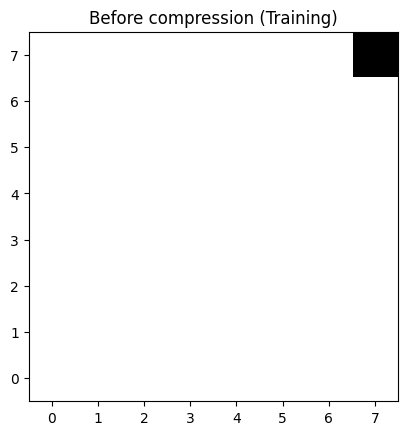

After compression (Training)
Shape: (1, 8, 8)


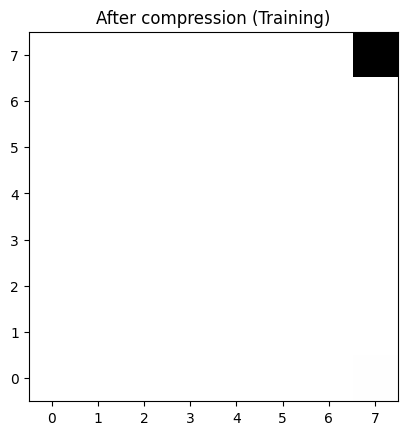

Epoch 122/200: 100%|██████████| 199/199 [00:00<00:00, 336.73it/s, Loss (BCE + VQ)=0.0436]


Epoch [122/200] summary:Average Loss: VQ + BCE = 0.0436,  Average loss: BCE = 0.0370 MSE = 0.0030561850626190106 avg_perplexity = 9.803583945461254
Average validation set BCE loss: 0.03946273624897003


Epoch 123/200: 100%|██████████| 199/199 [00:00<00:00, 330.20it/s, Loss (BCE + VQ)=0.0369]


Epoch [123/200] summary:Average Loss: VQ + BCE = 0.0438,  Average loss: BCE = 0.0372 MSE = 0.003123549067054936 avg_perplexity = 9.789173169351702
Average validation set BCE loss: 0.03993597477674484


Epoch 124/200: 100%|██████████| 199/199 [00:00<00:00, 330.00it/s, Loss (BCE + VQ)=0.0399]


...

Epoch [134/200] summary:Average Loss: VQ + BCE = 0.0429,  Average loss: BCE = 0.0366 MSE = 0.0029910072630467874 avg_perplexity = 9.958510926021404
Average validation set BCE loss: 0.03992062211036682


Epoch 135/200: 100%|██████████| 199/199 [00:00<00:00, 333.35it/s, Loss (BCE + VQ)=0.0386]


Epoch [135/200] summary:Average Loss: VQ + BCE = 0.0427,  Average loss: BCE = 0.0364 MSE = 0.0029457706060663016 avg_perplexity = 9.983868589353321
Average validation set BCE loss: 0.038846152275800704


Epoch 136/200: 100%|██████████| 199/199 [00:00<00:00, 336.67it/s, Loss (BCE + VQ)=0.0416]


Epoch [136/200] summary:Average Loss: VQ + BCE = 0.0425,  Average loss: BCE = 0.0363 MSE = 0.0029131283377526545 avg_perplexity = 9.976828723696608
Average validation set BCE loss: 0.040041332691907884
Before compression (Training)
Shape: (13, 8, 8)


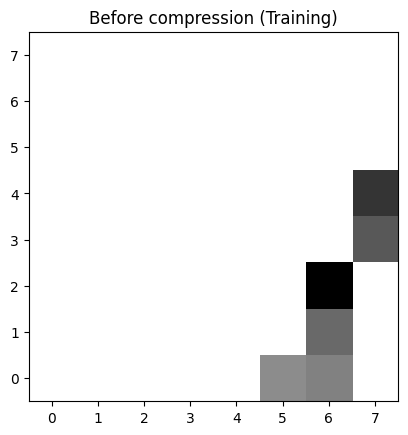

After compression (Training)
Shape: (1, 8, 8)


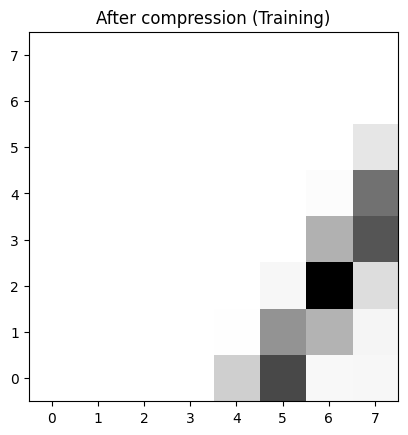

Epoch 137/200: 100%|██████████| 199/199 [00:00<00:00, 340.03it/s, Loss (BCE + VQ)=0.0485]


Epoch [137/200] summary:Average Loss: VQ + BCE = 0.0425,  Average loss: BCE = 0.0363 MSE = 0.002920091994593491 avg_perplexity = 9.991514943951938
Average validation set BCE loss: 0.0397364042699337


Epoch 138/200: 100%|██████████| 199/199 [00:00<00:00, 335.59it/s, Loss (BCE + VQ)=0.0522]


Epoch [138/200] summary:Average Loss: VQ + BCE = 0.0432,  Average loss: BCE = 0.0367 MSE = 0.0030062557361907696 avg_perplexity = 10.057248465379878
Average validation set BCE loss: 0.03933177515864372


Epoch 139/200: 100%|██████████| 199/199 [00:00<00:00, 318.23it/s, Loss (BCE + VQ)=0.0348]


...

Epoch [149/200] summary:Average Loss: VQ + BCE = 0.0416,  Average loss: BCE = 0.0358 MSE = 0.002811845722514668 avg_perplexity = 10.235249423501479
Average validation set BCE loss: 0.03864049836993218


Epoch 150/200: 100%|██████████| 199/199 [00:00<00:00, 328.59it/s, Loss (BCE + VQ)=0.0365]


Epoch [150/200] summary:Average Loss: VQ + BCE = 0.0417,  Average loss: BCE = 0.0359 MSE = 0.00284561898966493 avg_perplexity = 10.25498182210491
Average validation set BCE loss: 0.0393311507999897


Epoch 151/200: 100%|██████████| 199/199 [00:00<00:00, 324.29it/s, Loss (BCE + VQ)=0.0406]


Epoch [151/200] summary:Average Loss: VQ + BCE = 0.0420,  Average loss: BCE = 0.0361 MSE = 0.0028948075823654333 avg_perplexity = 10.257861559115463
Average validation set BCE loss: 0.03860999494791031
Before compression (Training)
Shape: (13, 8, 8)


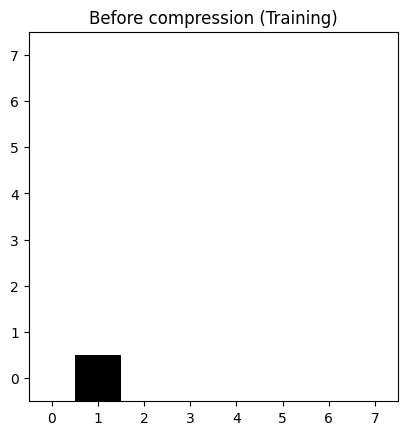

After compression (Training)
Shape: (1, 8, 8)


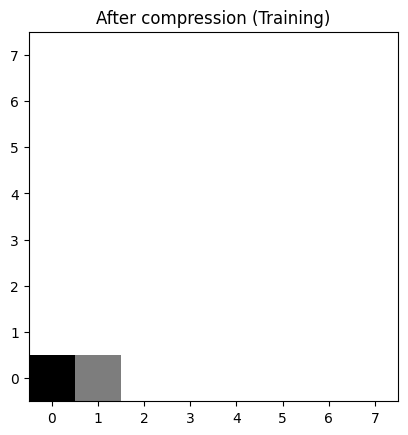

Epoch 152/200: 100%|██████████| 199/199 [00:00<00:00, 313.53it/s, Loss (BCE + VQ)=0.0411]


Epoch [152/200] summary:Average Loss: VQ + BCE = 0.0415,  Average loss: BCE = 0.0358 MSE = 0.0028326120286075464 avg_perplexity = 10.276162732186629
Average validation set BCE loss: 0.03802267834544182


Epoch 153/200: 100%|██████████| 199/199 [00:00<00:00, 332.18it/s, Loss (BCE + VQ)=0.041] 


Epoch [153/200] summary:Average Loss: VQ + BCE = 0.0418,  Average loss: BCE = 0.0360 MSE = 0.0028479826963043317 avg_perplexity = 10.286681481941262
Average validation set BCE loss: 0.03911571726202965


Epoch 154/200: 100%|██████████| 199/199 [00:00<00:00, 342.26it/s, Loss (BCE + VQ)=0.042] 


...

Epoch [164/200] summary:Average Loss: VQ + BCE = 0.0408,  Average loss: BCE = 0.0353 MSE = 0.002702962158449069 avg_perplexity = 10.391144182214784
Average validation set BCE loss: 0.03840874135494232


Epoch 165/200: 100%|██████████| 199/199 [00:00<00:00, 342.14it/s, Loss (BCE + VQ)=0.0331]


Epoch [165/200] summary:Average Loss: VQ + BCE = 0.0408,  Average loss: BCE = 0.0354 MSE = 0.0027163759857912234 avg_perplexity = 10.376766813460307
Average validation set BCE loss: 0.038703879714012145


Epoch 166/200: 100%|██████████| 199/199 [00:00<00:00, 342.01it/s, Loss (BCE + VQ)=0.0415]


Epoch [166/200] summary:Average Loss: VQ + BCE = 0.0406,  Average loss: BCE = 0.0352 MSE = 0.002680855305940287 avg_perplexity = 10.395572585676184
Average validation set BCE loss: 0.03935242369771004
Before compression (Training)
Shape: (13, 8, 8)


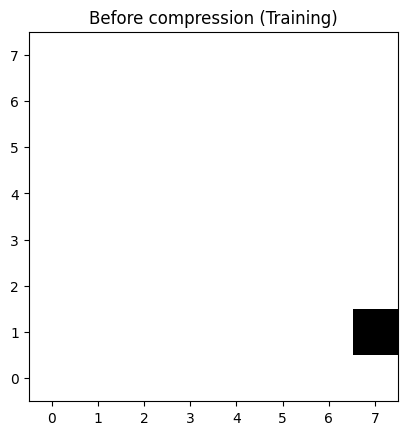

After compression (Training)
Shape: (1, 8, 8)


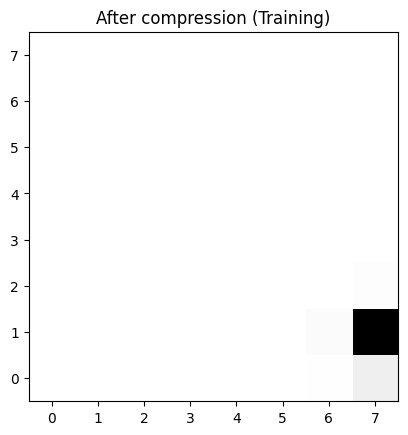

Epoch 167/200: 100%|██████████| 199/199 [00:00<00:00, 310.72it/s, Loss (BCE + VQ)=0.0367]


Epoch [167/200] summary:Average Loss: VQ + BCE = 0.0407,  Average loss: BCE = 0.0353 MSE = 0.0026905666685770806 avg_perplexity = 10.371805234171038
Average validation set BCE loss: 0.03888395950198174


Epoch 168/200: 100%|██████████| 199/199 [00:00<00:00, 350.68it/s, Loss (BCE + VQ)=0.0704]


Epoch [168/200] summary:Average Loss: VQ + BCE = 0.0406,  Average loss: BCE = 0.0353 MSE = 0.002668427635129335 avg_perplexity = 10.392201485945352
Average validation set BCE loss: 0.03854397311806679


Epoch 169/200: 100%|██████████| 199/199 [00:00<00:00, 336.62it/s, Loss (BCE + VQ)=0.0476]


...

Epoch [179/200] summary:Average Loss: VQ + BCE = 0.0401,  Average loss: BCE = 0.0348 MSE = 0.0025953241739768403 avg_perplexity = 10.468651258765753
Average validation set BCE loss: 0.03984355926513672


Epoch 180/200: 100%|██████████| 199/199 [00:00<00:00, 340.25it/s, Loss (BCE + VQ)=0.0385]


Epoch [180/200] summary:Average Loss: VQ + BCE = 0.0400,  Average loss: BCE = 0.0348 MSE = 0.002581886089542628 avg_perplexity = 10.453737220572467
Average validation set BCE loss: 0.03901829645037651


Epoch 181/200: 100%|██████████| 199/199 [00:00<00:00, 345.29it/s, Loss (BCE + VQ)=0.0411]


Epoch [181/200] summary:Average Loss: VQ + BCE = 0.0401,  Average loss: BCE = 0.0349 MSE = 0.0026099408038391093 avg_perplexity = 10.462113428355462
Average validation set BCE loss: 0.040044523775577545
Before compression (Training)
Shape: (13, 8, 8)


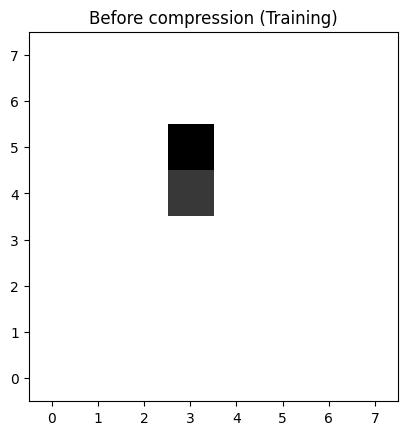

After compression (Training)
Shape: (1, 8, 8)


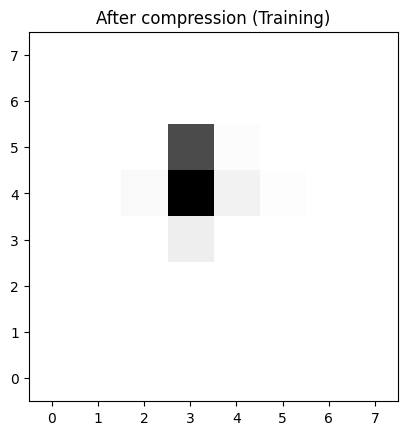

Epoch 182/200: 100%|██████████| 199/199 [00:00<00:00, 321.41it/s, Loss (BCE + VQ)=0.0313]


Epoch [182/200] summary:Average Loss: VQ + BCE = 0.0400,  Average loss: BCE = 0.0348 MSE = 0.0025766079183012695 avg_perplexity = 10.475972674000802
Average validation set BCE loss: 0.04024740010499954


Epoch 183/200: 100%|██████████| 199/199 [00:00<00:00, 331.99it/s, Loss (BCE + VQ)=0.0355]


Epoch [183/200] summary:Average Loss: VQ + BCE = 0.0398,  Average loss: BCE = 0.0346 MSE = 0.002544040242373831 avg_perplexity = 10.481819660819356
Average validation set BCE loss: 0.038873236253857614


Epoch 184/200: 100%|██████████| 199/199 [00:00<00:00, 340.33it/s, Loss (BCE + VQ)=0.0301]


...

Epoch [194/200] summary:Average Loss: VQ + BCE = 0.0396,  Average loss: BCE = 0.0345 MSE = 0.0025214284539091677 avg_perplexity = 10.544143240655487
Average validation set BCE loss: 0.03995849266648292


Epoch 195/200: 100%|██████████| 199/199 [00:00<00:00, 347.21it/s, Loss (BCE + VQ)=0.0368]


Epoch [195/200] summary:Average Loss: VQ + BCE = 0.0397,  Average loss: BCE = 0.0346 MSE = 0.0025401970280343714 avg_perplexity = 10.577468325744322
Average validation set BCE loss: 0.04005720838904381


Epoch 196/200: 100%|██████████| 199/199 [00:00<00:00, 338.88it/s, Loss (BCE + VQ)=0.0473]


Epoch [196/200] summary:Average Loss: VQ + BCE = 0.0395,  Average loss: BCE = 0.0344 MSE = 0.0025012902786777395 avg_perplexity = 10.559980205555059
Average validation set BCE loss: 0.039529141038656235
Before compression (Training)
Shape: (13, 8, 8)


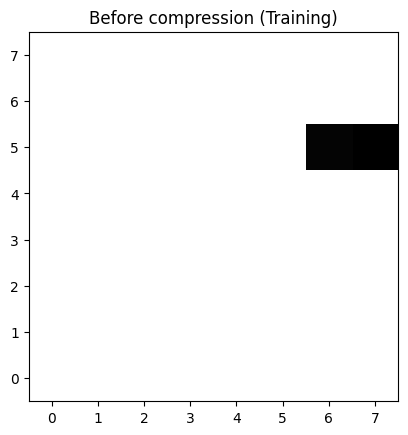

After compression (Training)
Shape: (1, 8, 8)


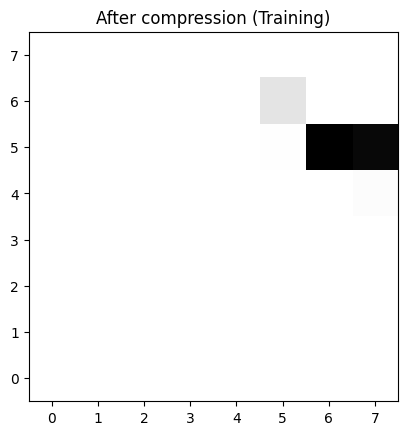

Epoch 197/200: 100%|██████████| 199/199 [00:00<00:00, 324.30it/s, Loss (BCE + VQ)=0.0365]


Epoch [197/200] summary:Average Loss: VQ + BCE = 0.0397,  Average loss: BCE = 0.0346 MSE = 0.0025320031701226778 avg_perplexity = 10.58206722125336
Average validation set BCE loss: 0.03927404172718525


Epoch 198/200: 100%|██████████| 199/199 [00:00<00:00, 331.83it/s, Loss (BCE + VQ)=0.0451]


Epoch [198/200] summary:Average Loss: VQ + BCE = 0.0396,  Average loss: BCE = 0.0345 MSE = 0.0025025634592324123 avg_perplexity = 10.587747674491537
Average validation set BCE loss: 0.038546984642744066


Epoch 199/200: 100%|██████████| 199/199 [00:00<00:00, 336.33it/s, Loss (BCE + VQ)=0.0441]


Epoch [199/200] summary:Average Loss: VQ + BCE = 0.0397,  Average loss: BCE = 0.0345 MSE = 0.0025013634892901283 avg_perplexity = 10.587765794303548
Average validation set BCE loss: 0.03892902694642544


Epoch 200/200: 100%|██████████| 199/199 [00:00<00:00, 338.19it/s, Loss (BCE + VQ)=0.0441]


Epoch [200/200] summary:Average Loss: VQ + BCE = 0.0395,  Average loss: BCE = 0.0344 MSE = 0.002496385829284525 avg_perplexity = 10.595287495522044
Average validation set BCE loss: 0.03864906057715416
Before compression (Validation)
Shape: (64, 8, 8)


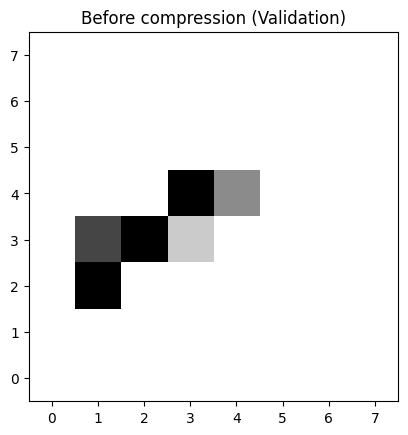

After compression (Validation)
Shape: (1, 8, 8)


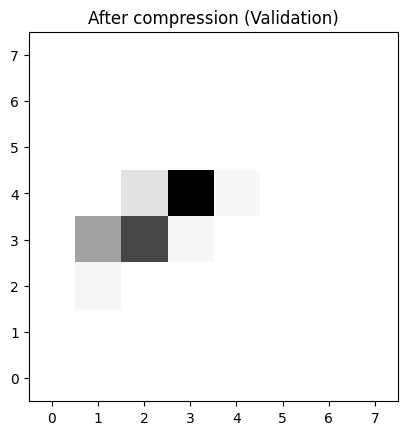

----------------------------------------
Patch = 0 compression results
----------------width_val------------------------
Patch encoder output dimensions:(w x h) = (4096) x (2)
Compression ratio = 0.001158600718362367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 65547.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


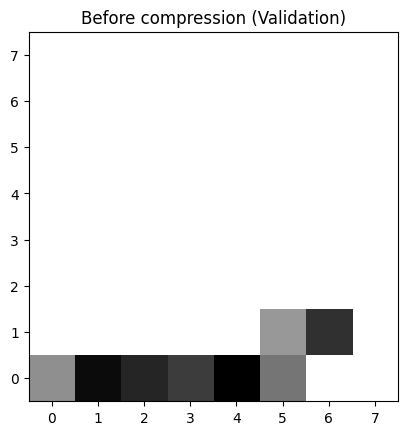

After compression (Validation)
Shape: (1, 8, 8)


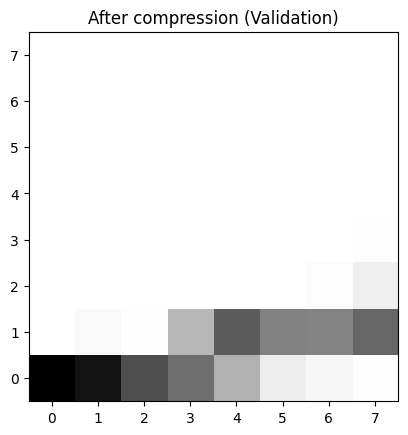

----------------------------------------
Patch = 1 compression results
----------------width_val------------------------
Patch encoder output dimensions:(w x h) = (4096) x (2)
Compression ratio = 0.001158600718362367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 65547.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


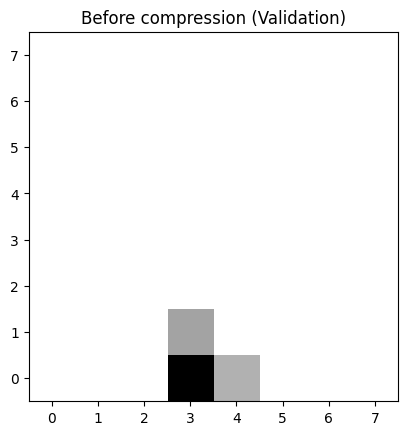

After compression (Validation)
Shape: (1, 8, 8)


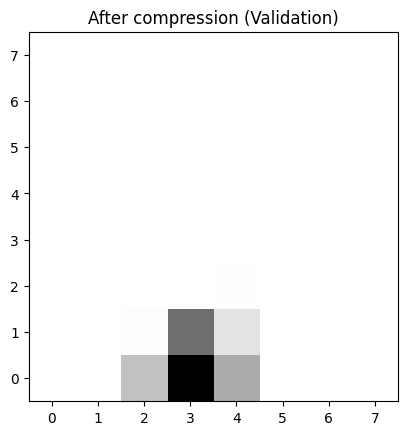

----------------------------------------
Patch = 2 compression results
----------------width_val------------------------
Patch encoder output dimensions:(w x h) = (4096) x (2)
Compression ratio = 0.001158600718362367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 65547.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (64, 8, 8)


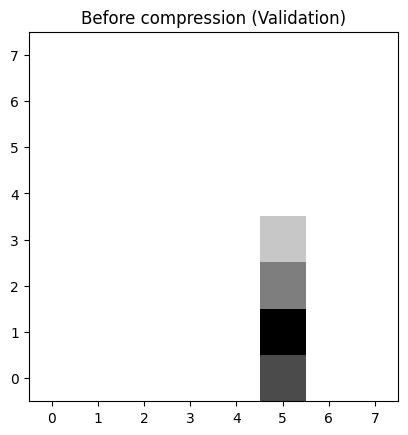

After compression (Validation)
Shape: (1, 8, 8)


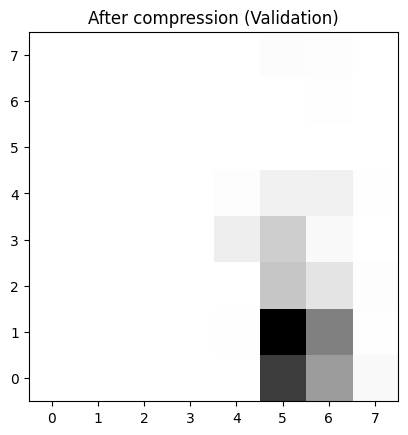

----------------------------------------
Patch = 3 compression results
----------------width_val------------------------
Patch encoder output dimensions:(w x h) = (4096) x (2)
Compression ratio = 0.001158600718362367
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 65547.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Before compression (Validation)
Shape: (61, 8, 8)


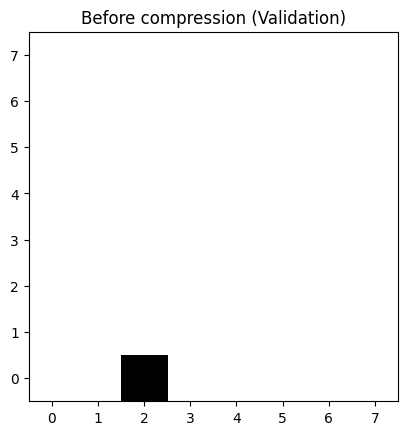

After compression (Validation)
Shape: (1, 8, 8)


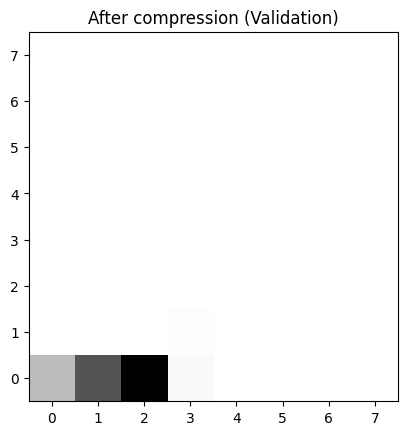

----------------------------------------
Patch = 4 compression results
----------------width_val------------------------
Patch encoder output dimensions:(w x h) = (3904) x (2)
Compression ratio = 0.0012155710490035707
total_hit_amount = 48169
total_hit_bits = 1204225
patch_amount = 15857
encoded_patch_bits = 62475.0 (1 patch 8 x 8)
num_embeddings = 256
Codebook dimensions: 256 x 32
----------------------------------------
Saving trained model VQ-VAE


In [21]:
# BCE loss average values
average_loss_train = []
average_loss_values_val = []
average_loss_train_bce = []

# Patches (validation)
patches_before_val = []
patches_after_val = []
patches_encodings_val = [] # latent vector
patches_pairs_val = []

# Patches (training)
patches_before_train = []
patches_encodings_train = []
patches_after_train = []

# MSE residual averages
average_loss_train_mse = []
average_loss_valid_mse_val = []

# perplexity
average_perplexity_train = []
average_perplexity_val = []

plot_val_patches_limit = 25


for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_loss_bce = 0
    train_loss_mse = 0
    train_perplexity = 0
    
    progress_bar = tqdm(
        enumerate(train_loader),
        total=len(train_loader),
        desc=f'Epoch {epoch+1}/{num_epochs}'
    )
    
    for (batch_idx, X_adcs) in progress_bar:
        optimizer.zero_grad()
        
        X_adcs = X_adcs.float()
        X_adcs = X_adcs.to(device)
        
        (
            recon_patch, 
            codebook_train,
            _,
            perplexity,
            vq_loss
        ) = model(
           X_adcs
        )
        
        
        bce_loss = _get_vae_loss(recon_patch, X_adcs)
        total_vq_loss = bce_loss + vq_loss
        
        recon_patch_train = recon_patch.float().to(device)      
        train_loss += total_vq_loss.item()
        train_loss_bce += bce_loss.item()
        
        total_vq_loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=model_param_scale)
            
        train_loss_mse += mse(recon_patch_train, X_adcs).item()
        train_perplexity += perplexity.item()
        
        optimizer.step()        

        # Update tqdm description with current loss
        progress_bar.set_postfix({'Loss (BCE + VQ)': total_vq_loss.item()})
        # scheduler.step()
        
        
    avg_loss_bce_vq = train_loss / len(train_loader)
    avg_loss_mse = train_loss_mse / len(train_loader)
    avg_perplexity = train_perplexity / len(train_loader)
    avg_loss_bce = train_loss_bce / len(train_loader)
    
    print(
        f"Epoch [{epoch + 1}/{num_epochs}] summary:"
        f"Average Loss: VQ + BCE = {avg_loss_bce_vq:.4f}, ",
        f"Average loss: BCE = {avg_loss_bce:.4f}",
        f"MSE = {avg_loss_mse}",
        f"avg_perplexity = {avg_perplexity}"
    )
    
    average_loss_train.append(avg_loss_bce_vq)
    average_loss_train_mse.append(avg_loss_mse)
    average_perplexity_train.append(avg_perplexity)
    average_loss_train_bce.append(avg_loss_bce)
    
    # Test with validation set for checking error residuals
    with torch.no_grad():
        model.eval()
        total_bce_loss_val = 0
        total_mse_loss_val = 0
        
        # Calculating average erros 
        for patch_val in val_loader:
            patch_val = patch_val.to(device)  
            
            (
               recon_patch_val, 
               codebook_val, 
               z_q_val,
               perplexity_val,
               _,
            ) = model(patch_val)
            
            patch_bce_val = F.binary_cross_entropy(
                recon_patch_val,
                patch_val,
                reduction="mean"
            ).cpu().detach().numpy().item()
            total_bce_loss_val += patch_bce_val
            
            patch_mse_val = mse(
               patch_val,
               recon_patch_val  
            ).item()
            total_mse_loss_val += patch_mse_val
            
        average_loss_val = total_bce_loss_val / len(val_loader)
        average_loss_val_mse = total_mse_loss_val / len(val_loader)
        average_loss_values_val.append(average_loss_val)
        average_loss_valid_mse_val.append(average_loss_val_mse)
        
        print(f"Average validation set BCE loss: {average_loss_val}")
        # print("Last batch patch, compression metrics:")
        # for k, v in result.items():
        #     print(f"{k} = {v}")
    
        # Test with validation set for checking image reconstruction quality
    
        if epoch % LOG_EVERY == 0:
                # selecting events before reconstruction using one test loader as validation
                # plotting last training
                
                print("Before compression (Training)")                    
                X_adcs_ts = model_tool._tensor_to_numpy(
                    X_adcs.squeeze(1)
                )
                
                print(f"Shape: {X_adcs_ts.shape}")            
                cms_plots.plot_patch(X_adcs_ts[0], "Before compression (Training)")
                
                recon_patch_train_np = model_tool._tensor_to_numpy(
                    recon_patch_train[0]
                )
                print("After compression (Training)")
                print(f"Shape: {recon_patch_train_np.shape}")
                
                cms_plots.plot_patch(recon_patch_train_np[0], "After compression (Training)")
                
                if len(patches_after_train) < plot_val_patches_limit:
                    patches_before_train.append(X_adcs_ts[0])
                    patches_after_train.append(recon_patch_train_np[0])
                    patches_encodings_train.append(
                        model_tool._tensor_to_numpy(codebook_train)
                    )
                
        if epoch == num_epochs - 1:
            for (plot_idx, patch_val) in enumerate(val_loader):
                patch_val = patch_val.to(device)           
                patch_val = patch_val.float()
                (
                    recon_patch_val, 
                    codebook_val, 
                    z_q_val, 
                    perplexity_val,
                    _
                ) = model(patch_val)
                
                print("Before compression (Validation)")                    
                patch_val_ts_val = model_tool._tensor_to_numpy(
                    patch_val.squeeze(1)
                )
                
                print(f"Shape: {patch_val_ts_val.shape}")            
                cms_plots.plot_patch(patch_val_ts_val[0], "Before compression (Validation)")
                
                patches_before_val.append(patch_val_ts_val[0])
                
                recon_patch_np_val = model_tool._tensor_to_numpy(
                    recon_patch_val[0]
                )
                print("After compression (Validation)")
                print(f"Shape: {recon_patch_np_val.shape}")
                
                cms_plots.plot_patch(
                    recon_patch_np_val[0], 
                    "After compression (Validation)"
                )
            
                patches_after_val.append(recon_patch_np_val[0])  
                encodings_val_np = model_tool._tensor_to_numpy(codebook_val)
                patches_encodings_val.append(encodings_val_np) 
                
                width_val, height_val = z_q_val.shape
                c_width, c_height = codebook_val.shape
                
                print("----------------------------------------")
                print(f"Patch = {plot_idx} compression results")
                print("----------------width_val------------------------")
                print(
                    f"Patch encoder output dimensions:"
                    f"(w x h) = ({width_val}) x ({height_val})"
                )
                
                compression_ratio = cms_data_tool._get_compression_ratio(
                    n_hits_total=total_hit_amount,
                    patch_amount=patch_amount,
                    encoded_patch_size=(width_val, height_val, num_embeddings),
                    patch_size=PATCH_SIZE
                )
                total_bits = cms_data_tool._get_total_hit_bits(total_hit_amount)
                encoded_patch_bits = cms_data_tool._get_encoded_patch_bits(
                    (
                        width_val, 
                        height_val, 
                        num_embeddings
                    ), 
                    PATCH_SIZE
                )
                
                print(f"Compression ratio = {compression_ratio}")
                print(f"total_hit_amount = {total_hit_amount}")
                print(f"total_hit_bits = {total_bits}")
                print(f"patch_amount = {patch_amount}")
                print(f"encoded_patch_bits = {encoded_patch_bits} (1 patch {PATCH_SIZE} x {PATCH_SIZE})")
                print(f"num_embeddings = {num_embeddings}")
                print(f"Codebook dimensions: {c_width} x {c_height}")
                print("----------------------------------------")
            
# save model
print("Saving trained model VQ-VAE")
torch.save(model.state_dict(), "../bin/vqvae.pth")

<h3>VQ-VAE results analysis</h3>

In [22]:
total_bits = cms_data_tool._get_total_hit_bits(
    total_hit_amount
)


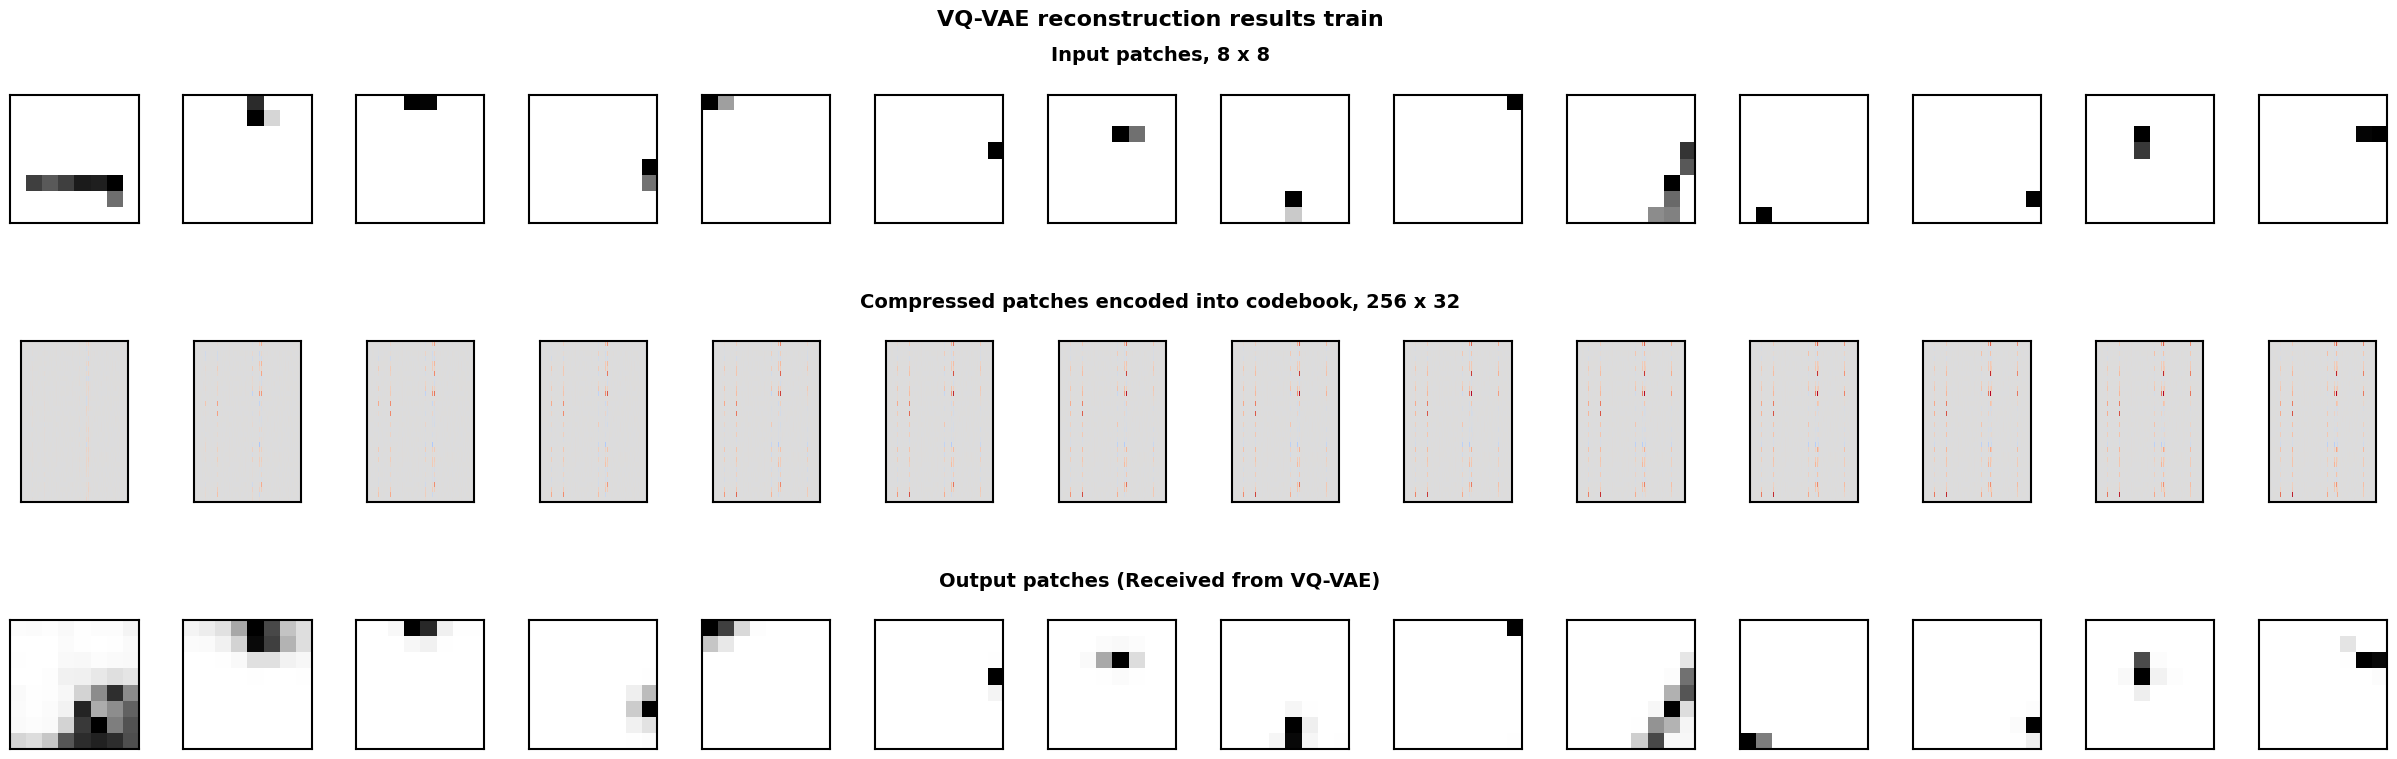

In [23]:
patch_rows = [
    (patches_before_train, "Input patches, 8 x 8"),
    (
        patches_encodings_train, 
        f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
    ),
    (patches_after_train, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results train")

# NOTE: Some patches are blurry due to early collection in the epochs

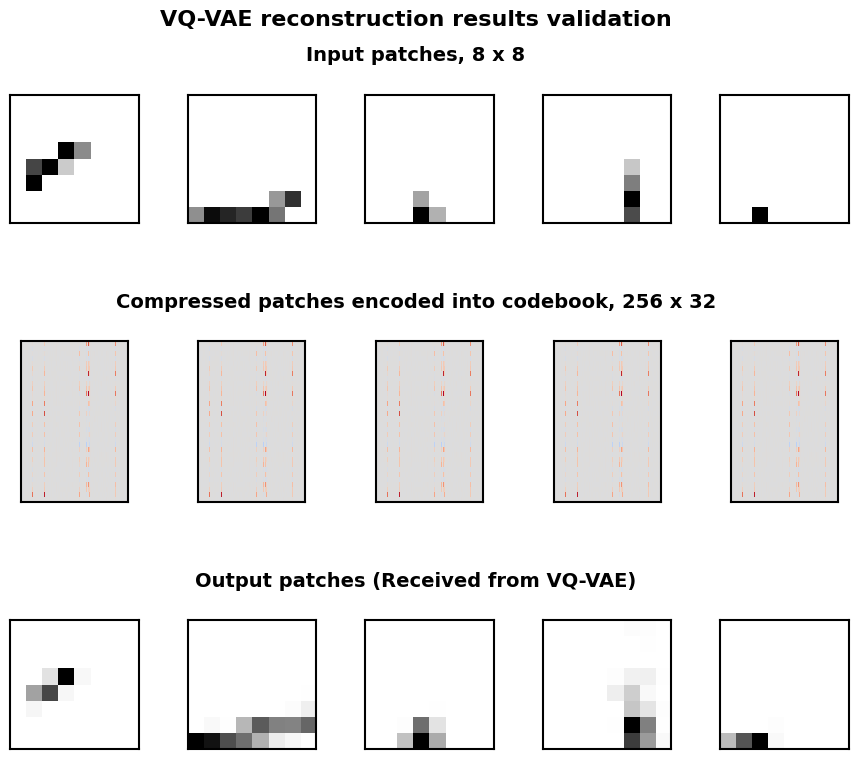

In [24]:
patch_rows = [
    (patches_before_val, "Input patches, 8 x 8"),
    (patches_encodings_val, 
     f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"
     ),
    (patches_after_val, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(
    patch_rows, 
    "VQ-VAE reconstruction results validation"
)

In [25]:
# TODO
# Improve gradients
model_tool._display_gradients(model)

Showing model gradients
encoder.0.weight 0.033797115087509155
encoder.1.weight 0.003813009476289153
encoder.1.bias 0.006565123796463013
encoder.3.weight 0.08087356388568878
encoder.4.weight 0.005943018477410078
encoder.4.bias 0.005383003503084183
encoder.6.weight 0.0895896852016449
encoder.7.weight 0.006182569544762373
encoder.7.bias 0.006288858596235514
encoder.8.stack.0.res_block.1.weight 0.036451417952775955
encoder.8.stack.0.res_block.3.weight 0.024952683597803116
encoder.8.stack.1.res_block.1.weight 0.04018097743391991
encoder.8.stack.1.res_block.3.weight 0.046836502850055695
fc_encoder_input.layers.0.weight 0.033119093626737595
fc_encoder_input.layers.0.bias 2.6031257704950406e-10
fc_encoder_input.layers.1.weight 0.008103655651211739
fc_encoder_input.layers.1.bias 0.008726222440600395
vq_layer.embedding.weight 0.0015505263581871986
fc_decoder_input.layers.0.weight 0.0035874447785317898
fc_decoder_input.layers.0.bias 1.862790632856104e-08
fc_decoder_input.layers.1.weight 0.0064716

VQ VAE, BCE encoder average loss values over epochs


/home/paulius/vq_vae_experiments/helpers/data_tool.py:124: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


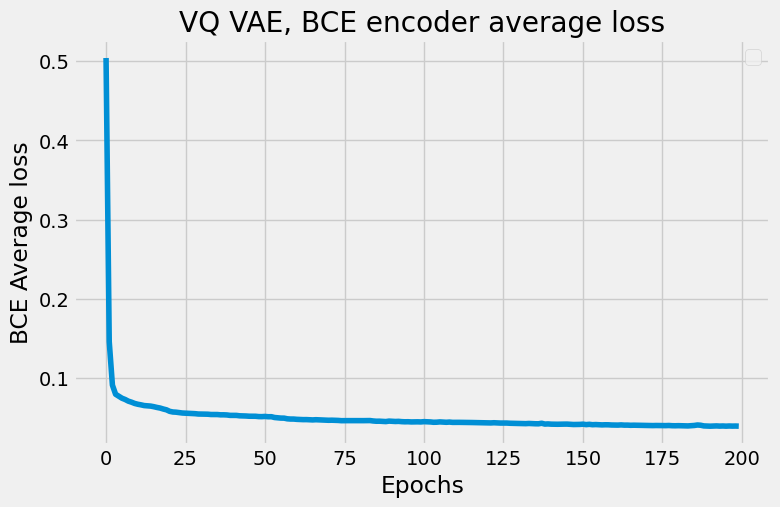

Saved VQ-VAE loss train data to csv
Saved VQ-VAE loss validation data to csv


In [26]:
# display loss values
cms_plots.plot_curve(
    y_values=average_loss_train, 
    x_values=list(range(num_epochs)),
    y_title="BCE Average loss",
    title="VQ VAE, BCE encoder average loss",
    x_label="Epochs"
)

# Saving train loss data
data_csv = pd.DataFrame(
    {
        "vq_average_loss" : average_loss_train,
        "bce_average_train_loss" : average_loss_train_bce,
        "mse_average_train_loss" : average_loss_train_mse,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_train.csv",index=False)
print("Saved VQ-VAE loss train data to csv")

# Saving validation loss data
data_csv = pd.DataFrame(
    {
        "bce_average_val_loss" : average_loss_values_val,
        "mse_average_val_loss" : average_loss_valid_mse_val,
        "epochs" : list(range(num_epochs))        
    }
)
data_csv.to_csv("vqvae_average_val.csv",index=False)
print("Saved VQ-VAE loss validation data to csv")


In [27]:
# Test set for testing using unseen data
model.load_state_dict(torch.load("../bin/vqvae.pth"))
model.eval()

bce_loss_values_test = []

patch_display_limit = 6
patches_after_test = []
patches_before_test = []
patches_encodings_test = [] # latent vector

bce_total_value = 0
perplexity_total = 0
test_set_size = len(test_loader)

for patch_test in test_loader:
    patch_test = patch_test.to(device)                     
    (
        recon_patch, 
        codebook_test, 
        z_q, 
        perplexity,
        _
    ) = model(patch_test)
    
    perplexity_total += perplexity.item()
    
    if len(patches_after_test) < patch_display_limit:
        patch_test_np = patch_test[0][0].cpu().detach().numpy()
        patches_before_test.append(patch_test_np)
        
        recon_patch_np = recon_patch[0][0].cpu().detach().numpy()
        patches_after_test.append(recon_patch_np)
        patches_encodings_test.append(
            model_tool._tensor_to_numpy(codebook_test)
        )
    
    # mse_loss = F.mse_loss(patch_test, recon_patch).item()
    bce_loss = F.binary_cross_entropy(
        patch_test, 
        recon_patch, 
        reduction="mean"
    ).cpu().detach().numpy().item()
    
    bce_total_value += bce_loss
    
bce_loss_average = bce_total_value / test_set_size
perplexity_average = perplexity_total / test_set_size

print(f"Based on test set (size = {test_set_size}), average BCE loss = {bce_loss_average:.5f}")
print(f"Based on test set (size = {test_set_size}), average codebook perplexity = {perplexity_average:.5f}/{num_embeddings}")

# saving
test_df_frame = pd.DataFrame(
    {
        "average_bce_loss_test" : [bce_loss_average],
        "average_perplexity_test" : [perplexity_average]
    }
)
test_df_frame.to_csv("vqvae_test_loss.csv")
print("Saved VQ-VAE test results")

Based on test set (size = 45), average BCE loss = 0.49905
Based on test set (size = 45), average codebook perplexity = 10.69233/256
Saved VQ-VAE test results


In [28]:
len(patches_before_test)

6

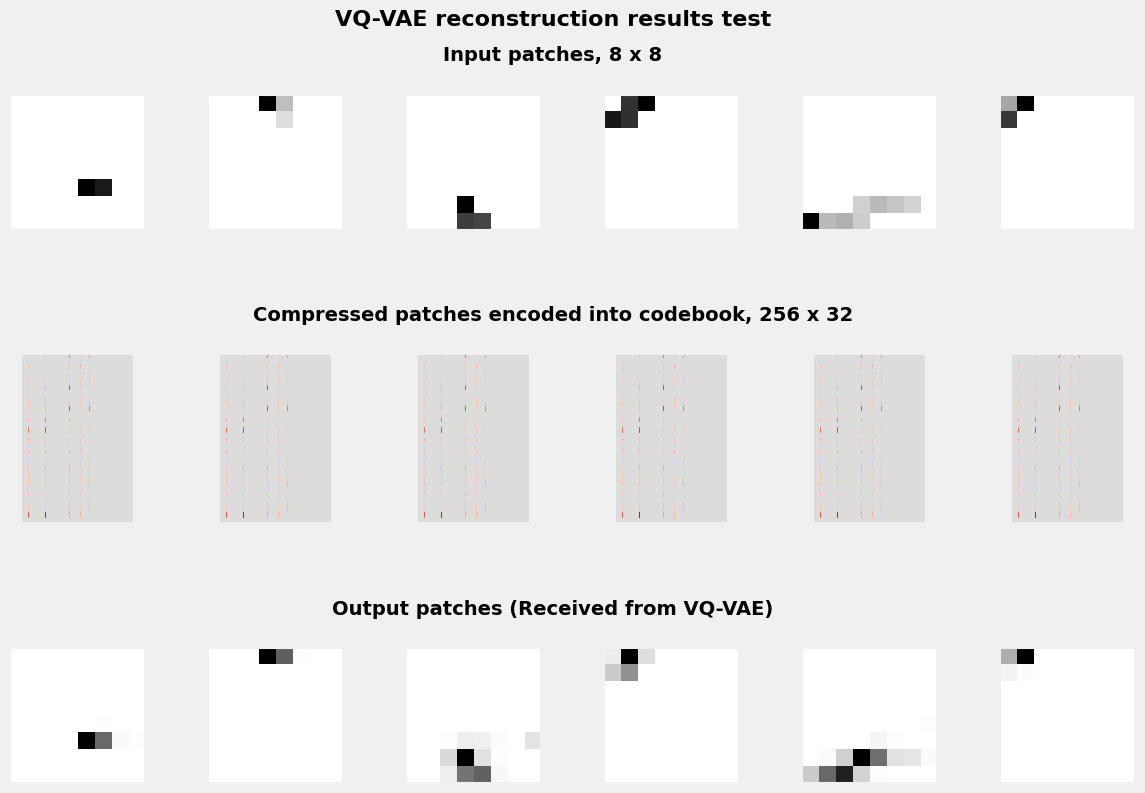

In [29]:
# Test dataset plotting part
patch_rows = [
    (patches_before_test, "Input patches, 8 x 8"),
    (patches_encodings_test, f"Compressed patches encoded into codebook, {num_embeddings} x {latent_dim}"),
    (patches_after_test, "Output patches (Received from VQ-VAE)")
]

cms_plots.plot_patches(patch_rows, "VQ-VAE reconstruction results test")

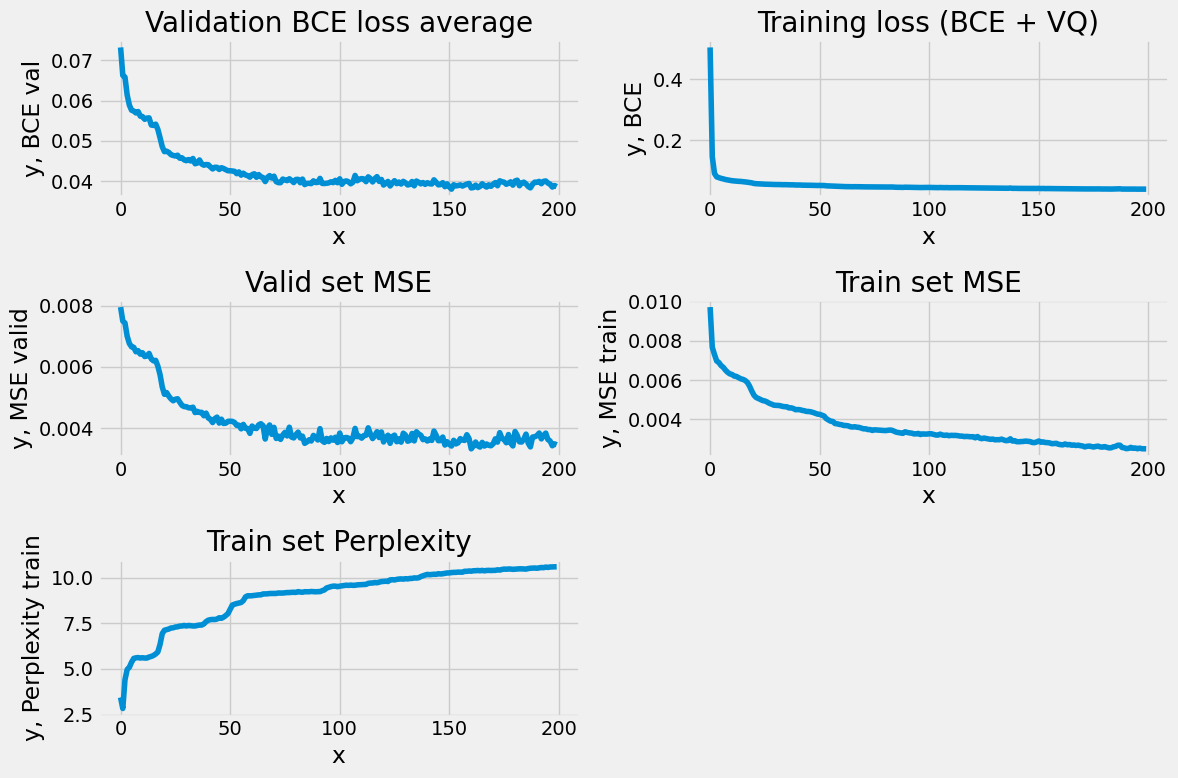

In [30]:
values_to_plot = [
    (list(range(len(average_loss_values_val))), average_loss_values_val, "Validation BCE loss average", "BCE val"),
    (list(range(len(average_loss_train))), average_loss_train, "Training loss (BCE + VQ)", "BCE"),
    (list(range(len(average_loss_valid_mse_val))), average_loss_valid_mse_val, "Valid set MSE", "MSE valid"),
    (list(range(len(average_loss_train_mse))), average_loss_train_mse, "Train set MSE", "MSE train"),
    (list(range(len(average_perplexity_train))), average_perplexity_train, "Train set Perplexity", "Perplexity train"),
]

cms_plots.plot_curves(values_to_plot)
